<a href="https://colab.research.google.com/github/nanyard/IA340/blob/main/Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
%pip -q install psycopg2-binary

import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from google.colab import userdata

In [45]:
try:
    conn = psycopg2.connect(
        host=userdata.get("DB_HOST"), port=5432,
        dbname=userdata.get("DB_NAME"), user=userdata.get("DB_USER"),
        password=userdata.get("DB_PASSWORD"),
        sslmode="require", connect_timeout=10)
except psycopg2.Error:
    raise RuntimeError("Check DB Secrets and database availability privately.") from None
cur = conn.cursor()
print("Connected.")

Connected.


In [46]:
conn.rollback()

In [47]:
cur.execute("INSERT INTO public.name (fips, name) VALUES ('51999', 'Practice County');")
conn.commit()
cur.execute("SELECT fips, name FROM public.name WHERE fips = '51999';")
print(cur.fetchall())

[('51999', 'Practice County')]


In [48]:
cur.execute("UPDATE public.name SET name = 'Practice County - Updated' WHERE fips = '51999';")
conn.commit()
cur.execute("SELECT fips, name FROM public.name WHERE fips = '51999';")
print(cur.fetchall())

[('51999', 'Practice County - Updated')]


In [49]:
cur.execute("DELETE FROM public.name WHERE fips = '51999';")
conn.commit()
cur.execute("SELECT fips, name FROM public.name WHERE fips = '51999';")
print(cur.fetchall())
conn.commit()

[]


In [50]:
try:
    cur.execute("""INSERT INTO public.name (fips, name)
                   VALUES (NULL, 'Practice County');""")
except psycopg2.errors.NotNullViolation:
    conn.rollback()
    print("Rejected NULL FIPS. The connection stays open.")
else:
    conn.rollback()
    raise RuntimeError("Expected primary-key rejection. Ask the instructor.")

cur.execute("SELECT name FROM public.name WHERE fips = '51059';")
print(cur.fetchall())
conn.commit()

Rejected NULL FIPS. The connection stays open.
[('Fairfax County',)]


In [65]:
sql_q0 = """
SELECT n.fips, n.name, p.year, p.population
FROM public.name AS n
INNER JOIN public.population AS p
  ON n.fips = p.fips
WHERE n.fips LIKE '51%' AND p.year = 2024
ORDER BY p.population DESC, n.fips;

"""

In [66]:
cur.execute(sql_q0)
rows = cur.fetchall()
columns = [col[0] for col in cur.description]
q0 = pd.DataFrame(rows, columns=columns)
display(q0)

,fips,name,year,population
0,51059,Fairfax County,2024,1160925
1,51153,Prince William County,2024,497003
2,51810,Virginia Beach city,2024,454808
3,51107,Loudoun County,2024,443380
4,51041,Chesterfield County,2024,389793
5,51087,Henrico County,2024,338696
6,51550,Chesapeake city,2024,254997
7,51013,Arlington County,2024,239807
8,51760,Richmond city,2024,233655
9,51710,Norfolk city,2024,231105


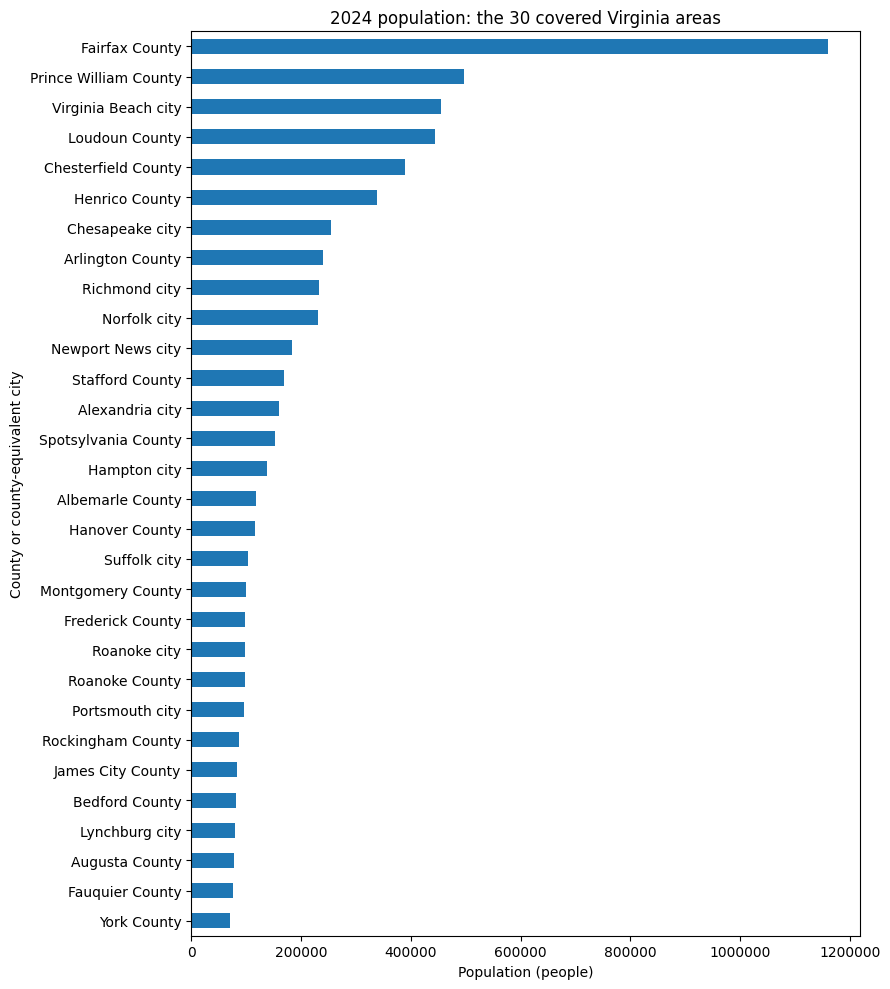

In [53]:
plot_q0 = q0.sort_values(["population", "fips"])
ax = plot_q0.plot.barh(x="name", y="population", legend=False, figsize=(9, 10))
ax.set_title("2024 population: the 30 covered Virginia areas")
ax.set_xlabel("Population (people)")
ax.set_ylabel("County or county-equivalent city")
ax.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

In [54]:
## Q1 - Population Growth
### Question:

In [ ]:
### what was the annual population growth rate in York County from 2015–2024, compared with the previous calendar year?

In [ ]:
### SQL

In [55]:
sql_q1 = """
SELECT
  "t1"."fips" AS "fips",
  "t1"."year" AS "year",
  "t2"."population" AS "previous_value",
  "t1"."population" AS "current_value",
  CASE
    WHEN "t2"."population" IS NULL THEN NULL
    WHEN "t2"."population" = 0 THEN NULL
    ELSE (("t1"."population" - "t2"."population")::double precision / "t2"."population"::double precision)
END
  AS "growth_rate"
FROM
  "population" AS "t1"
INNER JOIN
  "name" AS "n"
ON
  "t1"."fips" = "n"."fips"
LEFT JOIN
  "population" AS "t2"
ON
  "t1"."fips" = "t2"."fips"
  AND "t1"."year" = "t2"."year" + 1
WHERE
  "n"."name" = 'York County'
ORDER BY
  "year" ASC
NULLS LAST

"""

In [ ]:
### Python/Pandas

In [56]:
cur.execute(sql_q1)
rows = cur.fetchall()
columns = [col[0] for col in cur.description]
q1 = pd.DataFrame(rows, columns=columns)
display(q1)

,fips,year,previous_value,current_value,growth_rate
0,51199,2015,NaN,67837,NaN
1,51199,2016,67837.0,67976,0.002049
2,51199,2017,67976.0,67739,-0.003487
3,51199,2018,67739.0,67846,0.001580
4,51199,2019,67846.0,68280,0.006397
5,51199,2021,NaN,70915,NaN
6,51199,2022,70915.0,71341,0.006007
7,51199,2023,71341.0,70952,-0.005453
8,51199,2024,70952.0,71410,0.006455


In [ ]:
### Visualization

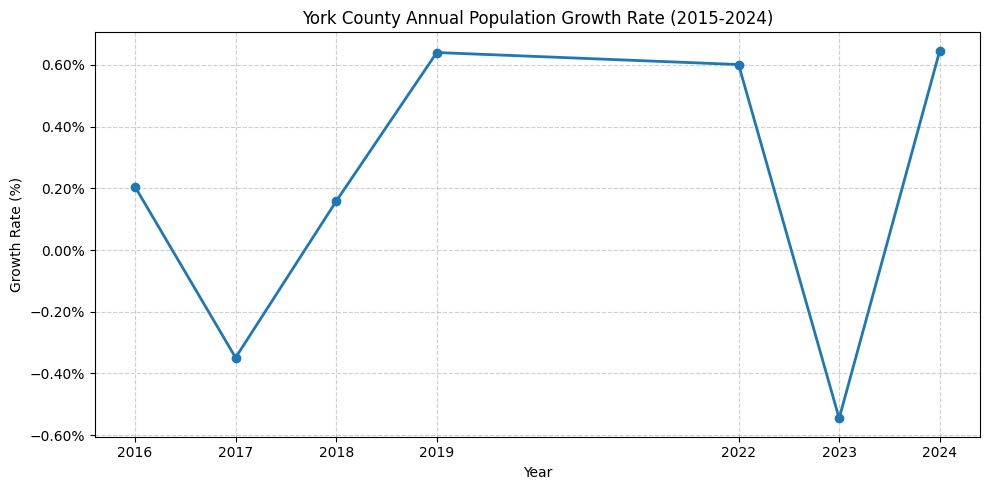

In [57]:
plot_df = q1.dropna(subset=['growth_rate'])

plt.figure(figsize=(10, 5))
plt.plot(plot_df['year'], plot_df['growth_rate'] * 100, marker='o', color='tab:blue', linewidth=2)

plt.title('York County Annual Population Growth Rate (2015-2024)')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(plot_df['year'])

import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

In [ ]:
### Interpretation:

In [ ]:
### York County has consistently been growing since 2015. Since it's only negavie values were both above -.6% and it had 3 years over .6%, the years of decrease are cancelled out.

In [ ]:
## Q2
### Question:

In [ ]:
### What was the annual growth rate of nominal median household income in York County from 2015 to 2024?

In [ ]:
### SQL

In [71]:
sql_q2 = """
SELECT
  "t1"."fips" AS "fips",
  "t1"."year" AS "year",
  "t2"."income" AS "previous_value",
  "t1"."income" AS "current_value",
  CASE
    WHEN "t2"."income" IS NULL THEN NULL
    WHEN "t2"."income" = 0 THEN NULL
    ELSE (("t1"."income" - "t2"."income")::double precision / "t2"."income"::double precision)
END
  AS "growth_rate"
FROM
  "income" AS "t1"
INNER JOIN
  "name" AS "n"
ON
  "t1"."fips" = "n"."fips"
LEFT JOIN
  "income" AS "t2"
ON
  "t1"."fips" = "t2"."fips"
  AND "t1"."year" = "t2"."year" + 1
WHERE
  "n"."name" = 'York County'
ORDER BY
  "year" ASC
NULLS LAST

"""

In [ ]:
### Python/Pandas

In [72]:
cur.execute(sql_q2)
rows = cur.fetchall()
columns = [col[0] for col in cur.description]
q2 = pd.DataFrame(rows, columns=columns)
display(q2)

,fips,year,previous_value,current_value,growth_rate
0,51199,2015,NaN,84580,NaN
1,51199,2016,84580.0,89418,0.057200
2,51199,2017,89418.0,83993,-0.060670
3,51199,2018,83993.0,83593,-0.004762
4,51199,2019,83593.0,91241,0.091491
5,51199,2021,NaN,97758,NaN
6,51199,2022,97758.0,116524,0.191964
7,51199,2023,116524.0,101351,-0.130214
8,51199,2024,101351.0,108815,0.073645


In [ ]:
### Visualization

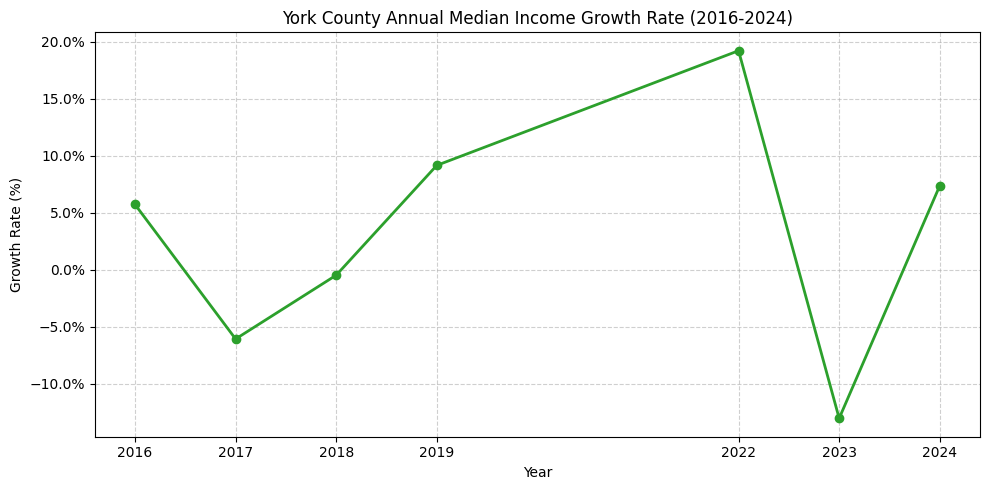

In [74]:
plot_q2_df = q2.dropna(subset=['growth_rate'])

plt.figure(figsize=(10, 5))
plt.plot(plot_q2_df['year'], plot_q2_df['growth_rate'] * 100, marker='o', color='tab:green', linewidth=2)

plt.title('York County Annual Median Income Growth Rate (2016-2024)')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(plot_q2_df['year'])

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

In [ ]:
### Interpretation:

In [ ]:
### York County has on average increased in median household income. There is one anomaly which is the strong decrease from 2022 to 2023, going from the highest increase to the lowest decrease in one year.

In [ ]:
## Q3
### Question:

In [ ]:
### What was the median household income per capita in York County 2015-2024?

In [ ]:
### SQL

In [79]:
sql_q3 = """
SELECT
  "t_inc"."fips" AS "fips",
  "t_inc"."year" AS "year",
  "t_pop"."population" AS "current_population",
  "t_inc"."income" AS "current_income",
  CAST("t_inc"."income" AS DOUBLE PRECISION) / CAST("t_pop"."population" AS DOUBLE PRECISION) AS "income_per_person"
FROM
  "name" AS "n"
INNER JOIN
  "income" AS "t_inc"
ON
  "n"."fips" = "t_inc"."fips"
INNER JOIN
  "population" AS "t_pop"
ON
  "t_inc"."fips" = "t_pop"."fips"
  AND "t_inc"."year" = "t_pop"."year"
WHERE
  "n"."name" = 'York County'
  AND "t_inc"."fips" IS NOT NULL
  AND "t_inc"."year" IS NOT NULL
  AND "t_pop"."population" IS NOT NULL
  AND "t_inc"."income" IS NOT NULL
ORDER BY
  "t_inc"."year" ASC
NULLS LAST

"""

In [ ]:
### Python/Pandas

In [80]:
cur.execute(sql_q3)
rows = cur.fetchall()
columns = [col[0] for col in cur.description]
q3 = pd.DataFrame(rows, columns=columns)
display(q3)

,fips,year,current_population,current_income,income_per_person
0,51199,2015,67837,84580,1.246812
1,51199,2016,67976,89418,1.315435
2,51199,2017,67739,83993,1.239950
3,51199,2018,67846,83593,1.232099
4,51199,2019,68280,91241,1.336277
5,51199,2021,70915,97758,1.378524
6,51199,2022,71341,116524,1.633338
7,51199,2023,70952,101351,1.428445
8,51199,2024,71410,108815,1.523806


In [ ]:
### Visualization

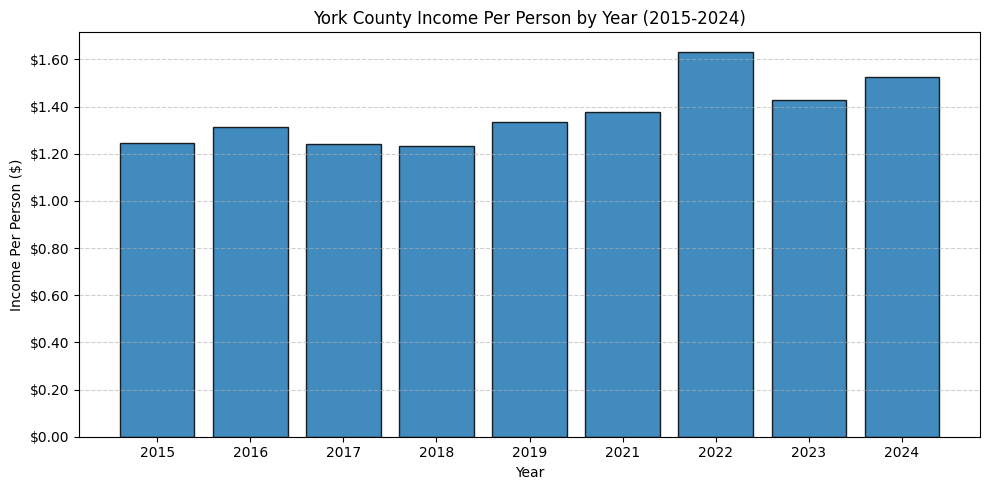

In [81]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Ensure the data is sorted chronologically
q3_sorted = q3.sort_values('year')

# Create the bar chart
plt.figure(figsize=(10, 5))
plt.bar(q3_sorted['year'].astype(str), q3_sorted['income_per_person'], color='tab:blue', edgecolor='black', alpha=0.85)

# Set labels and title
plt.title('York County Income Per Person by Year (2015-2024)')
plt.xlabel('Year')
plt.ylabel('Income Per Person ($)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Format y-axis values as currency
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('$%1.2f'))

plt.tight_layout()
plt.show()

In [ ]:
### Interpretation:

In [ ]:
### The median household income per person has stayed realatively similar from year to year. The standout year was 2022 which makes sense as we saw in the last graph, 2022 saw the largest increase in median household income.

In [ ]:
### I completed all three and used Gemini to create the visualizations.

In [ ]:
### Gemini also helped create the SQL code for each question. I checked it's answers by running the code and seeing if what it produced was accurate, and if not I rewrote my prompt.